# Sentiment Analysis Optimization using Bio Inspired Algorithm
## Dataset provided : https://archive.ics.uci.edu/dataset/331/sentiment+labelled+sentences
3 TSV Files 
### Members 
- Aniruddha Panchal
- kinjal Surve
- Tanuj Balivada
- Vanshika Chinchkhede

Models experimented :
- KNN (F1 )
- KNN (SPECIFICITY)

- RANDOM FOREST (F1)
- RANDOM FOREST (SPECIFICITY)

- DECISION TREE (F1)
- DECISION TREE (SPECIFICITY)

- SUM (F1)
- SUM (SPECIFICITY)

- GRADIENT B (F1)
- GRADIENT B (SPECIFICITY)

- XGRADIENT B (F1)
- XGRADIENT B (SPECIFICITY)

## Dataset analysis 

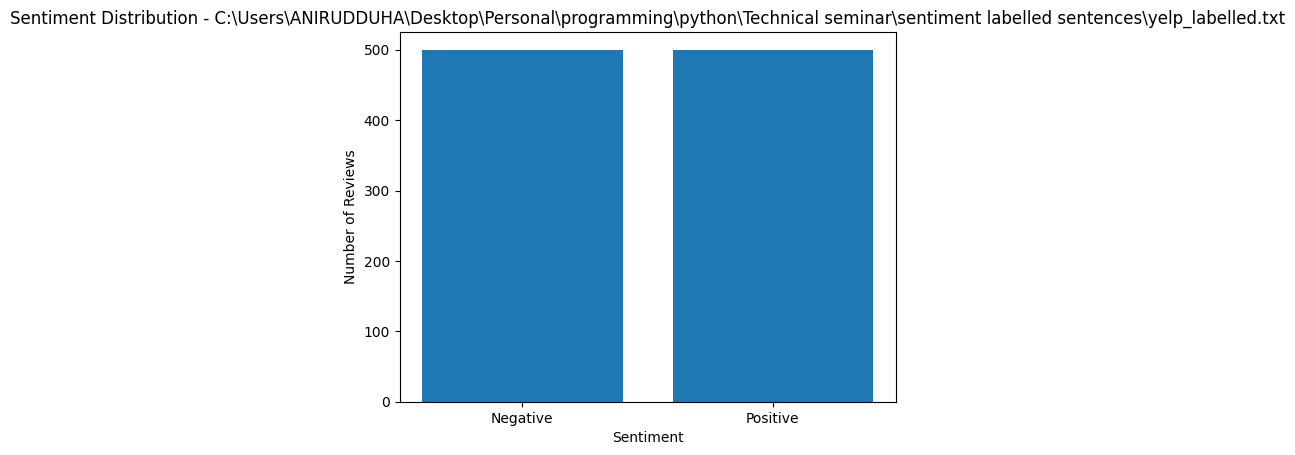

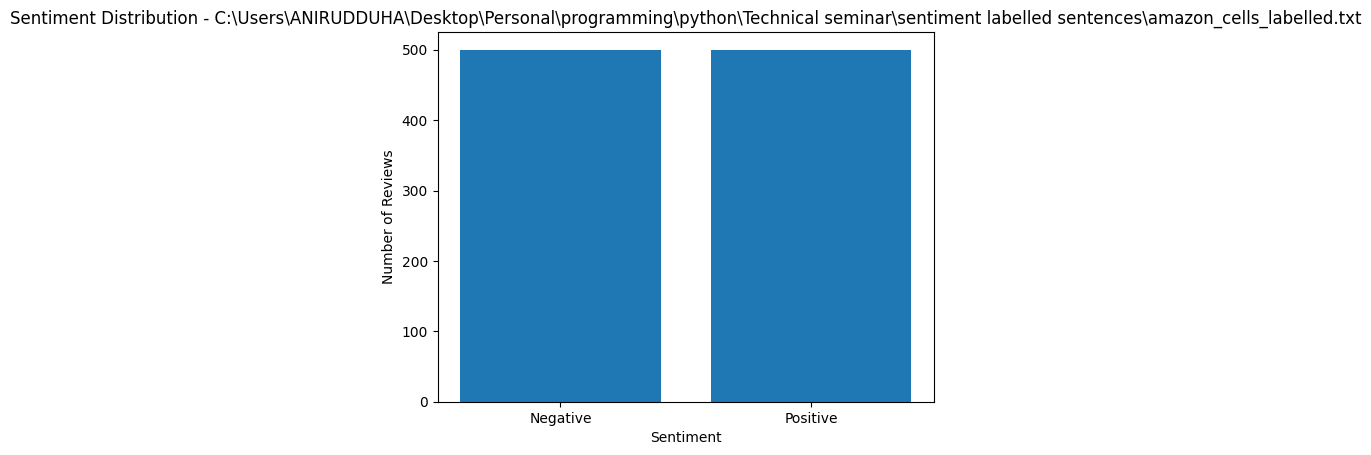

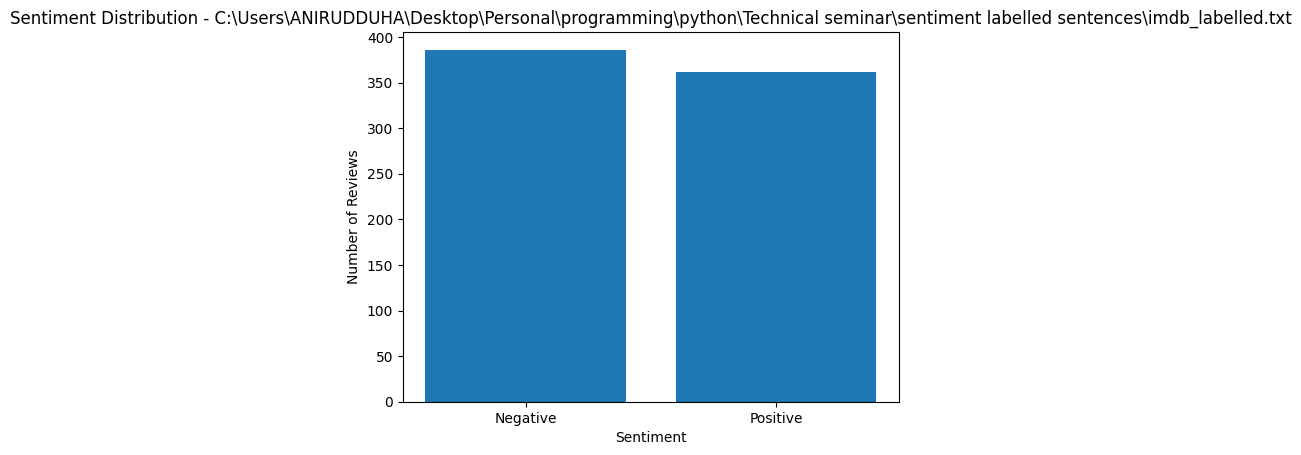

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# List of files
files = ['C:\\Users\\ANIRUDDUHA\\Desktop\\Personal\\programming\\python\\Technical seminar\\sentiment labelled sentences\\yelp_labelled.txt', "C:\\Users\\ANIRUDDUHA\\Desktop\\Personal\\programming\\python\\Technical seminar\\sentiment labelled sentences\\amazon_cells_labelled.txt", 'C:\\Users\\ANIRUDDUHA\\Desktop\\Personal\\programming\\python\\Technical seminar\\sentiment labelled sentences\\imdb_labelled.txt']

# Loop through files
for file in files:
    df = pd.read_csv(file, sep='\t', header=None, names=['text', 'label'])
    counts = df['label'].value_counts()
    
    plt.bar(['Negative', 'Positive'], counts)
    plt.title(f'Sentiment Distribution - {file}')
    plt.xlabel('Sentiment')
    plt.ylabel('Number of Reviews')
    plt.show()


 The data in the first two datasets is roughly balanced between positive and negative classes, whereas the third dataset (IMDb ratings) has a slightly higher number of negative samples; however, this minor imbalance can be safely ignored.

## KNN (PSO)

In [2]:
import pandas as pd

files = ["yelp_labelled.txt", "imdb_labelled.txt", "amazon_cells_labelled.txt"]

dfs = [pd.read_csv(f, sep='\t', header=None, names=['statement', 'value']) for f in files]

data = pd.concat(dfs, ignore_index=True)

X = data['statement']
y = data['value']


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = CountVectorizer(max_features=500)  # limit vocab for PSO
X_train_vect = vectorizer.fit_transform(X_train)
X_test_vect = vectorizer.transform(X_test)


In [4]:
from pyswarm import pso
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score
import numpy as np

def objective(features_mask):
    features_mask = np.array(features_mask) > 0.5
    if np.sum(features_mask) == 0:
        return 1.0  # penalty for empty feature set
    X_train_sel = X_train_vect[:, features_mask]
    X_test_sel = X_test_vect[:, features_mask]
    
    model = MultinomialNB()
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    f1 = f1_score(y_test, y_pred)
    return 1 - f1  # PSO minimizes


In [5]:
num_features = X_train_vect.shape[1]
lb = [0] * num_features
ub = [1] * num_features

best_features, best_cost = pso(objective, lb, ub, swarmsize=10, maxiter=5)

print("Best F1 Score:", 1 - best_cost)
print("Selected Features Indices:", np.where(np.array(best_features) > 0.5)[0])


Stopping search: maximum iterations reached --> 5
Best F1 Score: 0.75
Selected Features Indices: [  0   3   5   9  10  14  16  18  22  23  25  30  31  35  36  39  40  41
  42  44  45  47  49  51  55  57  60  61  64  68  70  71  73  74  75  76
  77  79  80  84  85  88  89  91  92  97  99 101 102 104 105 106 109 111
 112 114 116 119 120 122 123 125 126 129 133 136 137 138 140 141 144 146
 147 148 149 151 154 155 156 163 166 167 169 171 173 174 179 181 182 183
 184 185 186 187 190 194 200 202 203 206 207 208 210 212 213 214 215 216
 217 218 219 221 222 223 227 229 230 232 233 234 235 236 237 239 242 243
 244 246 249 250 251 256 259 262 263 264 268 270 274 275 278 279 281 284
 287 288 290 291 292 293 294 295 296 297 300 301 303 304 305 306 308 309
 311 315 316 317 322 327 328 330 333 334 335 336 339 342 343 345 347 351
 354 356 357 361 364 365 366 368 371 372 375 378 379 381 382 385 387 388
 389 390 393 394 395 397 398 400 402 409 411 413 415 416 418 421 422 424
 425 426 429 430 431 433 43